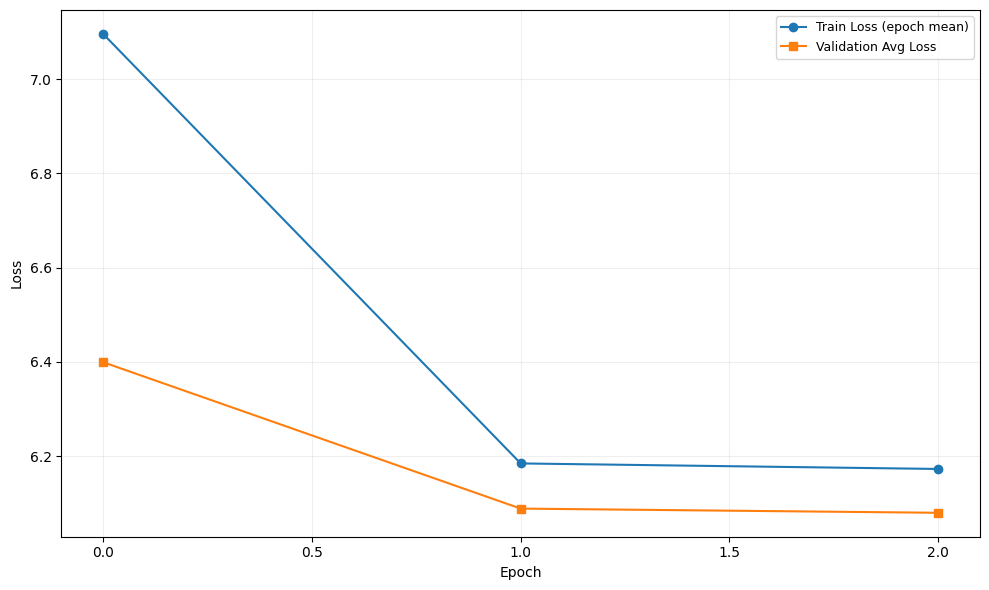

In [9]:
import matplotlib.pyplot as plt
import ast
import os
import numpy as np

def plot_synchronized_learning_curve(log_file_path):
    if not os.path.exists(log_file_path):
        print(f"Lỗi: Không tìm thấy file tại {log_file_path}")
        return

    # 1. Khởi tạo danh sách chứa dữ liệu thô
    train_data_raw = [] # (epoch, loss)
    val_data_raw = []   # (epoch, eval_loss)

    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('{'): continue
            
            try:
                # Parse dòng log thành dictionary
                data = ast.literal_eval(line)
                epoch = data.get('epoch')
                if epoch is None: continue
                
                # Lấy Train Loss
                if 'loss' in data:
                    train_data_raw.append((epoch, data['loss']))
                elif 'train_loss' in data:
                    train_data_raw.append((epoch, data['train_loss']))
                
                # Lấy Validation Loss
                if 'eval_loss' in data:
                    val_data_raw.append((epoch, data['eval_loss']))
            except:
                continue

    # 2. Hàm gom nhóm theo số NGUYÊN Epoch (1 epoch / 1 điểm)
    def aggregate_to_sync(raw_data):
        bins = {}
        for ep, loss in raw_data:
            idx = int(ep) # Gom 0.0 -> 0.99 vào epoch 0
            if idx not in bins: bins[idx] = []
            bins[idx].append(loss)
        
        sorted_epochs = sorted(bins.keys())
        mean_losses = [np.mean(bins[e]) for e in sorted_epochs]
        return sorted_epochs, mean_losses

    t_epochs, t_losses = aggregate_to_sync(train_data_raw)
    v_epochs, v_losses = aggregate_to_sync(val_data_raw)

    # 3. Đồng bộ hóa (chỉ lấy những Epoch mà cả hai đều có dữ liệu)
    common_epochs = sorted(list(set(t_epochs) & set(v_epochs)))
    sync_t_losses = [t_losses[t_epochs.index(e)] for e in common_epochs]
    sync_v_losses = [v_losses[v_epochs.index(e)] for e in common_epochs]

    # 4. Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    
    # Đường Train (Marker tròn)
    plt.plot(common_epochs, sync_t_losses, 
             label='Train Loss (epoch mean)', 
             marker='o', markersize=6, linewidth=1.5, color='#1f77b4')
    
    # Đường Val (Marker vuông)
    plt.plot(common_epochs, sync_v_losses, 
             label='Validation Avg Loss', 
             marker='s', markersize=6, linewidth=1.5, color='#ff7f0e')

    plt.xlabel('Epoch', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    
    # Lưới (kẻ nhạt)
    plt.grid(True, linestyle='-', alpha=0.2)
    
    # CHI TIẾT QUAN TRỌNG: Chia thanh Epoch (trục X) theo từng 0.5
    if common_epochs:
        max_ep = max(common_epochs)
        # np.arange(start, stop, step) -> Tạo các mốc 0.0, 0.5, 1.0, 1.5...
        plt.xticks(np.arange(0, max_ep + 0.5, 0.5))
    
    plt.legend(loc='upper right', fontsize=9, frameon=True)
    
    plt.tight_layout()
    plt.show()

# --- Cấu hình chạy ---
try:
    log_path = os.path.join(os.getcwd(), "phase1_train.log")
except NameError:
    log_path = "phase1_train.log"

plot_synchronized_learning_curve(log_path)

Đang đọc file log Phase 2...
Đã vẽ biểu đồ từ Epoch 2 đến 10.


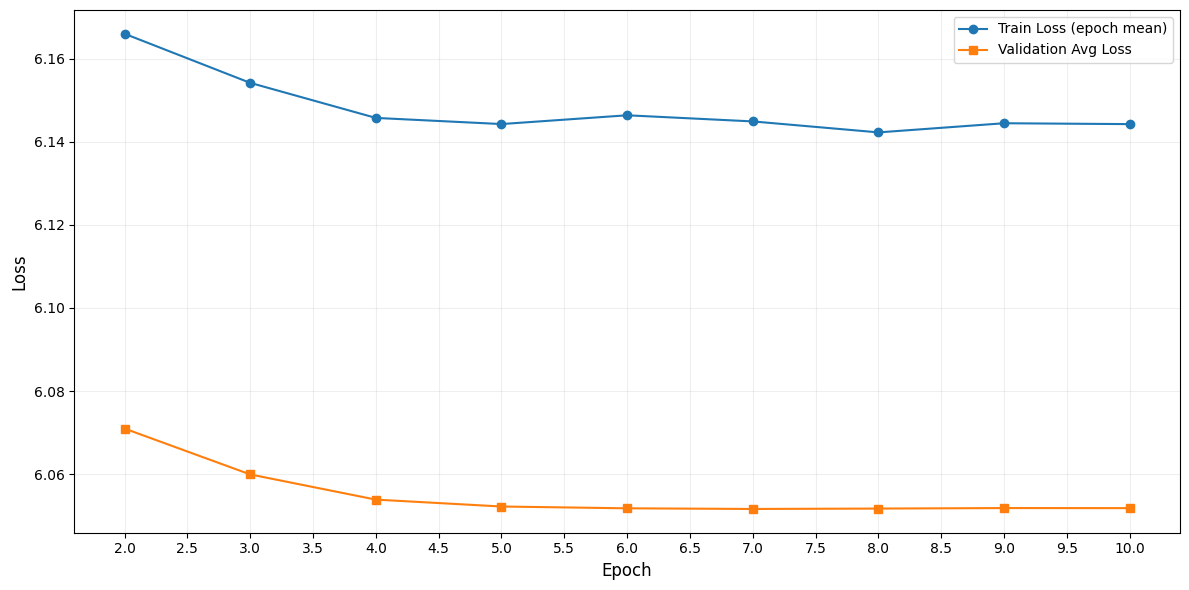

In [10]:
import matplotlib.pyplot as plt
import ast
import os
import numpy as np

def plot_phase2_learning_curve(log_file_path):
    if not os.path.exists(log_file_path):
        print(f"Lỗi: Không tìm thấy file tại {log_file_path}")
        return

    # Khởi tạo danh sách chứa dữ liệu thô
    train_data_raw = [] # (epoch, loss)
    val_data_raw = []   # (epoch, eval_loss)

    print("Đang đọc file log Phase 2...")
    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('{'): continue
            
            try:
                # Parse dòng log thành dictionary
                data = ast.literal_eval(line)
                epoch = data.get('epoch')
                if epoch is None: continue
                
                # Lấy Train Loss
                if 'loss' in data:
                    train_data_raw.append((epoch, data['loss']))
                elif 'train_loss' in data:
                    train_data_raw.append((epoch, data['train_loss']))
                
                # Lấy Validation Loss
                if 'eval_loss' in data:
                    val_data_raw.append((epoch, data['eval_loss']))
            except:
                continue

    # Hàm gom nhóm theo số NGUYÊN Epoch (1 epoch / 1 điểm)
    def aggregate_to_sync(raw_data):
        bins = {}
        for ep, loss in raw_data:
            idx = int(ep) # Gom 2.0 -> 2.99 vào epoch 2, 3.0 -> 3.99 vào epoch 3...
            if idx not in bins: bins[idx] = []
            bins[idx].append(loss)
        
        sorted_epochs = sorted(bins.keys())
        mean_losses = [np.mean(bins[e]) for e in sorted_epochs]
        return sorted_epochs, mean_losses

    t_epochs, t_losses = aggregate_to_sync(train_data_raw)
    v_epochs, v_losses = aggregate_to_sync(val_data_raw)

    # Đồng bộ hóa (chỉ lấy những Epoch mà cả hai đều có dữ liệu)
    common_epochs = sorted(list(set(t_epochs) & set(v_epochs)))
    if not common_epochs:
        print("Không tìm thấy epoch chung nào giữa Train và Val.")
        return

    sync_t_losses = [t_losses[t_epochs.index(e)] for e in common_epochs]
    sync_v_losses = [v_losses[v_epochs.index(e)] for e in common_epochs]

    # Bắt đầu vẽ biểu đồ
    plt.figure(figsize=(12, 6))
    
    # Đường Train (Marker tròn)
    plt.plot(common_epochs, sync_t_losses, 
             label='Train Loss (epoch mean)', 
             marker='o', markersize=6, linewidth=1.5, color='#1f77b4')
    
    # Đường Val (Marker vuông)
    plt.plot(common_epochs, sync_v_losses, 
             label='Validation Avg Loss', 
             marker='s', markersize=6, linewidth=1.5, color='#ff7f0e')

    # Định dạng tiêu đề và trục
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Lưới (kẻ nhạt)
    plt.grid(True, linestyle='-', alpha=0.2)
    
    # Chia thanh Epoch (trục X) theo từng 0.5
    min_ep = min(common_epochs)
    max_ep = max(common_epochs)
    plt.xticks(np.arange(min_ep, max_ep + 0.5, 0.5))
    
    plt.legend(loc='upper right', fontsize=10, frameon=True)
    
    plt.tight_layout()
    print(f"Đã vẽ biểu đồ từ Epoch {min_ep} đến {max_ep}.")
    plt.show()

# --- Chạy code ---
try:
    # Lấy đường dẫn thư mục hiện tại
    current_dir = os.path.dirname(os.path.abspath(__file__))
    log_path = os.path.join(current_dir, "phase2_train.log")
except NameError:
    # Dành cho môi trường Notebook / Colab
    log_path = os.path.join(os.getcwd(), "phase2_train.log")

plot_phase2_learning_curve(log_path)

Đang đọc file log Phase 3...
Đã vẽ biểu đồ từ Epoch 7 đến 11.


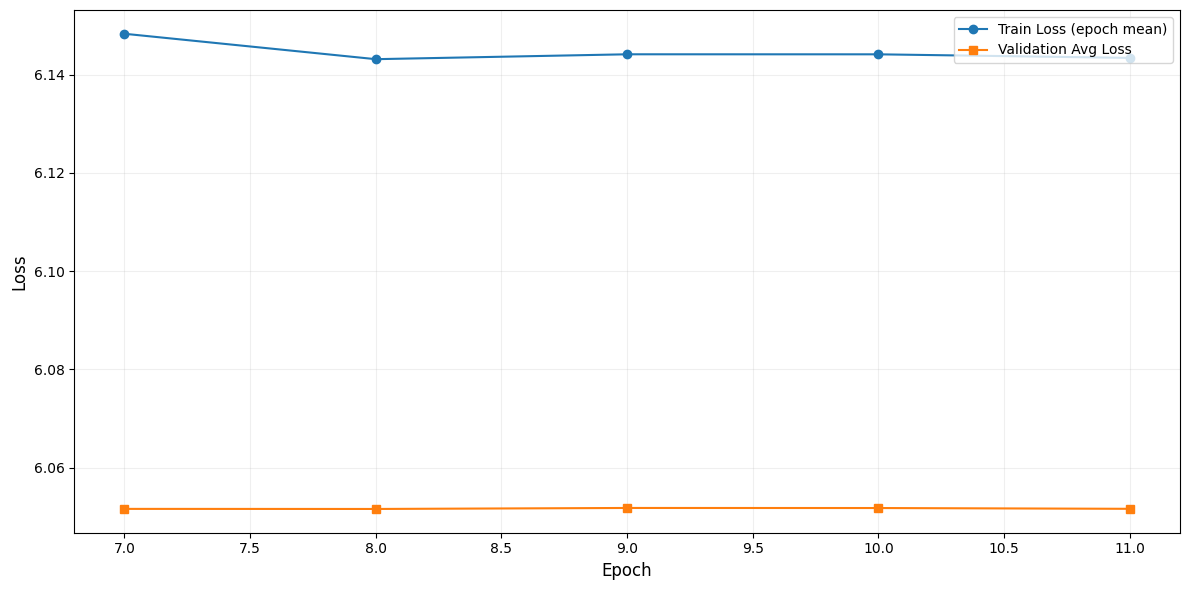

In [13]:
import matplotlib.pyplot as plt
import ast
import os
import numpy as np

def plot_phase3_learning_curve(log_file_path):
    if not os.path.exists(log_file_path):
        print(f"Lỗi: Không tìm thấy file tại {log_file_path}")
        return

    # Khởi tạo danh sách chứa dữ liệu
    train_data_raw = [] # (epoch, loss)
    val_data_raw = []   # (epoch, eval_loss)

    print("Đang đọc file log Phase 3...")
    with open(log_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('{'): continue
            
            try:
                data = ast.literal_eval(line)
                epoch = data.get('epoch')
                if epoch is None: continue
                
                # Lấy Train Loss
                if 'loss' in data:
                    train_data_raw.append((epoch, data['loss']))
                elif 'train_loss' in data:
                    train_data_raw.append((epoch, data['train_loss']))
                
                # Lấy Validation Loss
                if 'eval_loss' in data:
                    val_data_raw.append((epoch, data['eval_loss']))
            except:
                continue

    # Hàm gom nhóm theo số NGUYÊN Epoch để đồng bộ (VD: 7.26 -> Epoch 7)
    def aggregate_to_sync(raw_data):
        bins = {}
        for ep, loss in raw_data:
            idx = int(ep) 
            if idx not in bins: bins[idx] = []
            bins[idx].append(loss)
        
        sorted_epochs = sorted(bins.keys())
        mean_losses = [np.mean(bins[e]) for e in sorted_epochs]
        return sorted_epochs, mean_losses

    t_epochs, t_losses = aggregate_to_sync(train_data_raw)
    v_epochs, v_losses = aggregate_to_sync(val_data_raw)

    # Lấy các Epoch chung để đồng bộ 2 đường thẳng
    common_epochs = sorted(list(set(t_epochs) & set(v_epochs)))
    if not common_epochs:
        print("Không tìm thấy epoch chung nào giữa Train và Val.")
        return

    sync_t_losses = [t_losses[t_epochs.index(e)] for e in common_epochs]
    sync_v_losses = [v_losses[v_epochs.index(e)] for e in common_epochs]

    # Thiết lập và vẽ biểu đồ
    plt.figure(figsize=(12, 6))
    
    # Đường Train (Marker tròn)
    plt.plot(common_epochs, sync_t_losses, 
             label='Train Loss (epoch mean)', 
             marker='o', markersize=6, linewidth=1.5, color='#1f77b4')
    
    # Đường Val (Marker vuông)
    plt.plot(common_epochs, sync_v_losses, 
             label='Validation Avg Loss', 
             marker='s', markersize=6, linewidth=1.5, color='#ff7f0e')

    # Định dạng
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Lưới kẻ mờ
    plt.grid(True, linestyle='-', alpha=0.2)
    
    # Chia thanh Epoch (trục X) theo từng 0.5 để biểu đồ rộng và đẹp hơn
    min_ep = min(common_epochs)
    max_ep = max(common_epochs)
    plt.xticks(np.arange(min_ep, max_ep + 0.5, 0.5))
    
    plt.legend(loc='upper right', fontsize=10, frameon=True)
    
    plt.tight_layout()
    print(f"Đã vẽ biểu đồ từ Epoch {min_ep} đến {max_ep}.")
    plt.show()

# --- Chạy code ---
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
    log_path = os.path.join(current_dir, "phase3_train.log")
except NameError:
    # Hỗ trợ chạy trong Jupyter/Colab
    log_path = os.path.join(os.getcwd(), "phase3_train.log")

plot_phase3_learning_curve(log_path)